# Credit card customer segmentation project

**Importing libraries and models**

In [1]:
print("Importing Libraries...")

# ============================================================
# DATA SCIENCE LIBRARIES
# ============================================================

print("Importing Data Science Libraries...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# MACHINE LEARNING
# ============================================================

print("Importing Machine Learning Libraries...")

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ============================================================
# STANDARD LIBRARIES
# ============================================================

print("Importing Standard Libraries...")

import joblib
import datetime as dt
import warnings

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully.")

START_TIME = dt.datetime.now()

print(f"Project Started : {START_TIME}")

Importing Libraries...
Importing Data Science Libraries...
Importing Machine Learning Libraries...
Importing Standard Libraries...
Libraries Imported Successfully.
Project Started : 2026-08-01 15:19:50.658402


In [2]:
from pathlib import Path

# ============================================================
# PROJECT DIRECTORIES
# ============================================================

DATA_PATH = Path("../data")
MODELS_PATH = Path("../models")
PLOTS_PATH = Path("../plots")

MODELS_PATH.mkdir(exist_ok=True)
PLOTS_PATH.mkdir(exist_ok=True)

**Step 1 : Loading the Dataset**

In [3]:
FILE_PATH = DATA_PATH / "credit_card_customer_data.csv"

dataset = pd.read_csv(FILE_PATH)

**Step 2 : EDA**

In [4]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("="*60)
print("DATASET SHAPE")
print("="*60)
print(dataset.shape)

print("\n" + "="*60)
print("FIRST FIVE ROWS")
print("="*60)
display(dataset.head())

print("\n" + "="*60)
print("LAST FIVE ROWS")
print("="*60)
display(dataset.tail())

print("\n" + "="*60)
print("COLUMN NAMES")
print("="*60)
print(dataset.columns.tolist())

print("\n" + "="*60)
print("DATA TYPES")
print("="*60)
display(dataset.dtypes)

print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
dataset.info()

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
display(pd.DataFrame({
    "Missing Values": dataset.isnull().sum(),
    "Percentage (%)": (dataset.isnull().mean()*100).round(2)
}))

print("\n" + "="*60)
print("DUPLICATE ROWS")
print("="*60)
print(dataset.duplicated().sum())

print("\n" + "="*60)
print("UNIQUE VALUES")
print("="*60)
display(pd.DataFrame({
    "Unique Values": dataset.nunique()
}))

print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
display(dataset.describe().T)

print("\n" + "="*60)
print("CORRELATION MATRIX")
print("="*60)
display(dataset.corr(numeric_only=True))

print("\n" + "="*60)
print("OUTLIERS (IQR METHOD)")
print("="*60)

Q1 = dataset.quantile(0.25, numeric_only=True)
Q3 = dataset.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

outliers = (
    (
        dataset.select_dtypes(include="number")
        < (Q1 - 1.5 * IQR)
    )
    |
    (
        dataset.select_dtypes(include="number")
        > (Q3 + 1.5 * IQR)
    )
)

display(outliers.sum())

print("\nEDA Completed Successfully.")

DATASET SHAPE
(660, 7)

FIRST FIVE ROWS


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3



LAST FIVE ROWS


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
655,656,51108,99000,10,1,10,0
656,657,60732,84000,10,1,13,2
657,658,53834,145000,8,1,9,1
658,659,80655,172000,10,1,15,0
659,660,80150,167000,9,0,12,2



COLUMN NAMES
['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

DATA TYPES


...


CORRELATION MATRIX


,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Sl_No,1.000000,0.052886,0.677962,0.739329,0.406438,0.033916,-0.684125
Customer Key,0.052886,1.000000,0.068604,-0.010281,-0.000560,0.022506,0.005968
Avg_Credit_Limit,0.677962,0.068604,1.000000,0.608860,-0.100312,0.551385,-0.414352
Total_Credit_Cards,0.739329,-0.010281,0.608860,1.000000,0.315796,0.167758,-0.651251
Total_visits_bank,0.406438,-0.000560,-0.100312,0.315796,1.000000,-0.551861,-0.506016
Total_visits_online,0.033916,0.022506,0.551385,0.167758,-0.551861,1.000000,0.127299
Total_calls_made,-0.684125,0.005968,-0.414352,-0.651251,-0.506016,0.127299,1.000000



OUTLIERS (IQR METHOD)


Sl_No                   0
Customer Key            0
Avg_Credit_Limit       39
Total_Credit_Cards      0
Total_visits_bank       0
Total_visits_online    37
Total_calls_made        0
dtype: int64


EDA Completed Successfully.


**Step 3 : Data preprocessing**


In [5]:
print("=" * 60)
print("DATA PREPROCESSING")
print("=" * 60)

print("Dropping unnecessary columns...")

no_of_cols = dataset.shape[1]
dataset=dataset.drop(["Sl_No","Customer Key"],axis=1)
no_un_of_cols = dataset.shape[1]
print(str(no_of_cols-no_un_of_cols)+"/"+str(no_of_cols))

DATA PREPROCESSING
Dropping unnecessary columns...
2/7


In [6]:
print("Dropping duplicate rows and missing values...")

dataset = dataset.drop_duplicates()
dataset = dataset.dropna()

# Save original (unscaled) dataset
original_dataset = dataset.copy()

Dropping duplicate rows and missing values...


In [7]:
print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()

dataset = pd.DataFrame(
    scaler.fit_transform(dataset),
    columns=dataset.columns
)

FEATURE SCALING


In [8]:
print("This is how the dataset looks now:")
display(dataset.head())

This is how the dataset looks now:


,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1.723499,-1.247087,-0.860606,-0.550407,-1.248443
1,0.400209,-0.786701,-1.476410,2.499808,1.881237
2,0.400209,1.054846,-0.860606,0.127419,0.142526
3,-0.129107,0.134072,-0.860606,-0.550407,0.142526
4,1.723499,0.594459,-1.476410,3.177634,-0.205216


**Step 6 & 7: Elbow method / Silhouette score**

**Elbow Method**

In [9]:
inertia = []
silhouette_scores = []

for k in range(1,11):

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    labels = model.fit_predict(dataset)

    inertia.append(model.inertia_)

    if k > 1:

        score = silhouette_score(

            dataset,

            labels

        )

        silhouette_scores.append(score)

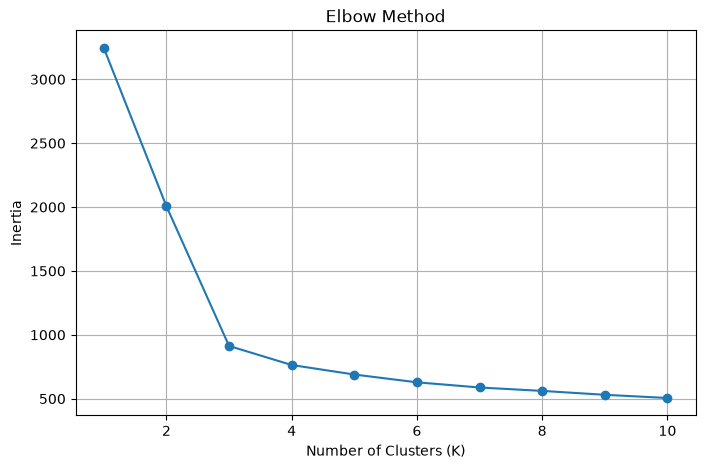

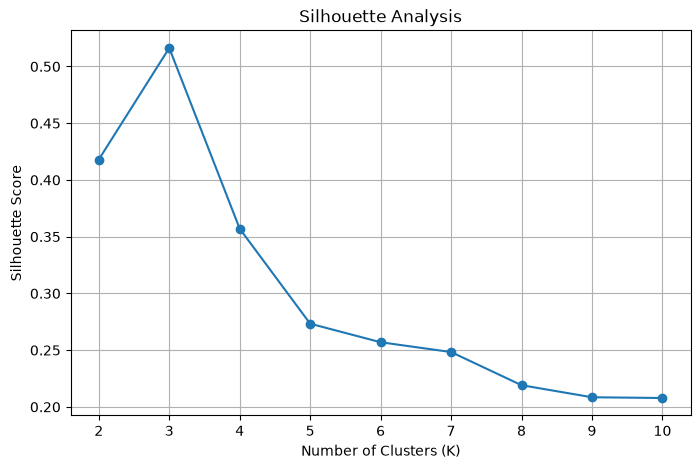

In [10]:
# ============================================================
# ELBOW METHOD
# ============================================================

ELBOW_FILE_PATH = PLOTS_PATH / "elbow_method.png"

plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)

plt.savefig(
    ELBOW_FILE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SILHOUETTE ANALYSIS
# ============================================================

SILHOUETTE_FILE_PATH = PLOTS_PATH / "silhouette_analysis.png"

plt.figure(figsize=(8,5))

plt.plot(range(2,11), silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)

plt.savefig(
    SILHOUETTE_FILE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Step 8 : Best K-means**

In [11]:
# ============================================================
# TRAIN FINAL K-MEANS MODEL
# ============================================================

BEST_K = 3

kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(dataset)

# Add cluster labels
dataset["Cluster"] = clusters
original_dataset["Cluster"] = clusters
print("=" * 60)
print("MODEL SUMMARY")
print("=" * 60)

print(f"Algorithm           : K-Means")
print(f"Clusters            : {BEST_K}")
print(f"Inertia             : {kmeans.inertia_:.2f}")
print(f"Silhouette Score    : {silhouette_score(dataset.drop('Cluster',axis=1), clusters):.3f}")

MODEL SUMMARY
Algorithm           : K-Means
Clusters            : 3
Inertia             : 912.86
Silhouette Score    : 0.516


**Step 9 : PCA Visualisation**

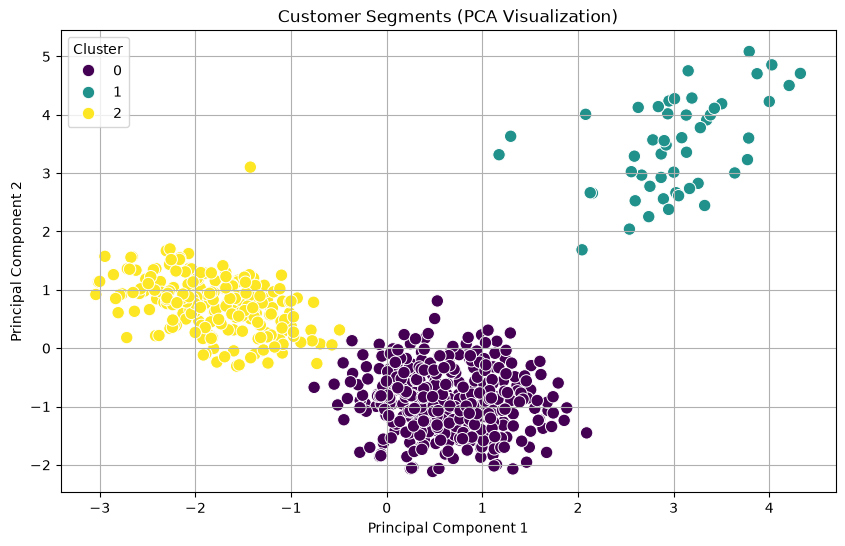

PCA SUMMARY
Variance Explained : 83.27%


In [12]:
# ============================================================
# PCA
# ============================================================

pca = PCA(n_components=2)

dataset_pca = pca.fit_transform(
    dataset.drop("Cluster", axis=1)
)

dataset_pca = pd.DataFrame(
    dataset_pca,
    columns=["PC1", "PC2"]
)

dataset_pca["Cluster"] = clusters

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=dataset_pca,

    x="PC1",

    y="PC2",

    hue="Cluster",

    palette="viridis",

    s=80

)

plt.title("Customer Segments (PCA Visualization)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

PCA_FILE_PATH = PLOTS_PATH / "pca_visualization.png"

plt.savefig(
    PCA_FILE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("PCA SUMMARY")
print("=" * 60)

print(
    f"Variance Explained : {pca.explained_variance_ratio_.sum()*100:.2f}%"
)

**Step 10 : Cluster analysis**

In [13]:
# ============================================================
# CLUSTER ANALYSIS
# ============================================================
cluster_summary = (
    original_dataset
    .groupby("Cluster")
    .mean()
    .round(2)
)

display(cluster_summary)

print("=" * 60)
print("CLUSTER SIZES")
print("=" * 60)

display(
    original_dataset["Cluster"].value_counts().sort_index()
)

CLUSTER_SUMMARY_PATH = Path("../results") / "cluster_summary.csv"

Path("../results").mkdir(exist_ok=True)

cluster_summary.to_csv(
    CLUSTER_SUMMARY_PATH
)

,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
Cluster,,,,,
0,34071.43,5.52,3.48,0.98,1.99
1,141040.00,8.74,0.60,10.90,1.08
2,12239.82,2.41,0.95,3.56,6.89


CLUSTER SIZES


Cluster
0    378
1     50
2    221
Name: count, dtype: int64

**Step 11 : Business Insights**

In [14]:
# ============================================================
# BUSINESS INSIGHTS
# ============================================================

print("=" * 60)
print("BUSINESS INSIGHTS")
print("=" * 60)

for cluster in cluster_summary.index:

    print(f"\nCluster {cluster}")
    print("-" * 60)

    for feature in cluster_summary.columns:

        value = cluster_summary.loc[cluster, feature]

        highest = cluster_summary[feature].idxmax()
        lowest = cluster_summary[feature].idxmin()

        if cluster == highest:

            print(f"✓ Highest {feature.replace('_',' ')} : {value:,.2f}")

        elif cluster == lowest:

            print(f"✓ Lowest {feature.replace('_',' ')} : {value:,.2f}")

        else:

            print(f"✓ Average {feature.replace('_',' ')} : {value:,.2f}")

    print("\nBusiness Interpretation:")

    if cluster == cluster_summary["Avg_Credit_Limit"].idxmax():

        print("- Premium / High-value customers")
        print("- Large spending capacity")
        print("- Eligible for premium banking services")

    elif cluster == cluster_summary["Avg_Credit_Limit"].idxmin():

        print("- Low-value customers")
        print("- Require more customer support")
        print("- Good candidates for basic banking products")

    else:

        print("- Medium-value customers")
        print("- Traditional banking behaviour")
        print("- Good opportunity for upselling")

print("\n" + "=" * 60)
print("CUSTOMER RANKING")
print("=" * 60)

ranking = cluster_summary["Avg_Credit_Limit"].sort_values(ascending=False)

for rank, cluster in enumerate(ranking.index, start=1):

    print(f"{rank}. Cluster {cluster}")

BUSINESS INSIGHTS

Cluster 0
------------------------------------------------------------
✓ Average Avg Credit Limit : 34,071.43
✓ Average Total Credit Cards : 5.52
✓ Highest Total visits bank : 3.48
✓ Lowest Total visits online : 0.98
✓ Average Total calls made : 1.99

Business Interpretation:
- Medium-value customers
- Traditional banking behaviour
- Good opportunity for upselling

Cluster 1
------------------------------------------------------------
✓ Highest Avg Credit Limit : 141,040.00
✓ Highest Total Credit Cards : 8.74
✓ Lowest Total visits bank : 0.60
✓ Highest Total visits online : 10.90
✓ Lowest Total calls made : 1.08

Business Interpretation:
- Premium / High-value customers
- Large spending capacity
- Eligible for premium banking services

Cluster 2
------------------------------------------------------------
✓ Lowest Avg Credit Limit : 12,239.82
✓ Lowest Total Credit Cards : 2.41
✓ Average Total visits bank : 0.95
✓ Average Total visits online : 3.56
✓ Highest Total cal

**Step 12 : Saving Models**

In [15]:
# ============================================================
# SAVING MODELS
# ============================================================

# Save K-Means Model
KMEANS_MODEL_PATH = MODELS_PATH / "kmeans_model.joblib"
joblib.dump(kmeans, KMEANS_MODEL_PATH)

# Save Scaler
SCALER_MODEL_PATH = MODELS_PATH / "scaler.joblib"
joblib.dump(scaler, SCALER_MODEL_PATH)

# Save PCA
PCA_MODEL_PATH = MODELS_PATH / "pca.joblib"
joblib.dump(pca, PCA_MODEL_PATH)

print("=" * 60)
print("MODELS SAVED SUCCESSFULLY")
print("=" * 60)
print(f"KMeans Model : {KMEANS_MODEL_PATH}")
print(f"Scaler       : {SCALER_MODEL_PATH}")
print(f"PCA          : {PCA_MODEL_PATH}")

RESULTS_PATH = Path("../results")
RESULTS_PATH.mkdir(exist_ok=True)

original_dataset.to_csv(
    RESULTS_PATH / "clustered_customers.csv",
    index=False
)

END_TIME = dt.datetime.now()

print(f"Project Finished : {END_TIME}")
print(f"Execution Time : {END_TIME - START_TIME}")

print("=" * 60)
print("PROJECT EXECUTED SUCCESSFULLY")
print("=" * 60)

print(f"Models saved  : {MODELS_PATH}")
print(f"Plots saved   : {PLOTS_PATH}")
print(f"Results saved : {RESULTS_PATH}")

MODELS SAVED SUCCESSFULLY
KMeans Model : ..\models\kmeans_model.joblib
Scaler       : ..\models\scaler.joblib
PCA          : ..\models\pca.joblib
Project Finished : 2026-08-01 15:20:04.125088
Execution Time : 0:00:13.466686
PROJECT EXECUTED SUCCESSFULLY
Models saved  : ..\models
Plots saved   : ..\plots
Results saved : ..\results
